## 차원 축소
* 독립변수의 개수를 2개로 줄임
### 왜?
* 속도 향상
* 노이즈 제거
* 시각화(독립변수가 2개=> 2차원 그래피, 3개=>3차원 그래프, 4개=>못함)


In [1]:
from sklearn.datasets import load_breast_cancer
# 데이터 생성
dataset = load_breast_cancer()

In [2]:
# 독립, 종속 분리(원래는 비지도이기 때문에 할 필요가 없음)
X, y = dataset.data , dataset.target

In [3]:
# 스케일링 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
from sklearn.decomposition import PCA
# n_components : 독립변수를 몇개로 줄일건지
model = PCA(n_components=2)
X_pca = model.fit_transform(X_scaled)

In [5]:
# 시각화 사전 작업
import pandas as pd
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y 
pca_df.head(3)

,PC1,PC2,target
0,9.192837,1.948583,0
1,2.387802,-3.768172,0
2,5.733896,-1.075174,0


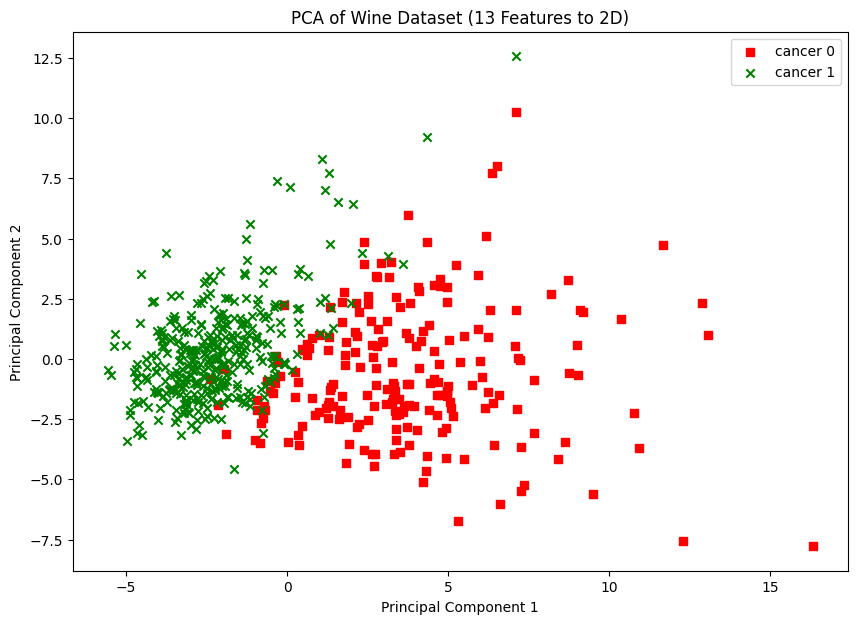

주성분 1 설명력: 0.44
주성분 2 설명력: 0.19
총 합계: 0.63


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=[10, 7])
colors = ['r', 'g']
markers = ['s', 'x']

# range(3) : 0~1 => 2개
# colors => 2개
# markers => 2개
for l, c, m in zip(range(2), colors, markers):
    plt.scatter(X_pca[y == l, 0], X_pca[y == l, 1], 
                c=c, label=f'cancer {l}', marker=m,)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.title('PCA of Wine Dataset (13 Features to 2D)')
plt.show()

# 각 주성분이 전체 분산의 몇 %를 설명하는지 출력
print(f"주성분 1 설명력: {model.explained_variance_ratio_[0]:.2f}")
print(f"주성분 2 설명력: {model.explained_variance_ratio_[1]:.2f}")
print(f"총 합계: {sum(model.explained_variance_ratio_):.2f}")